# Lab 8: Dataset Suitability, Dimensionality Reduction and Clustering

**Course:** Machine Learning Lab (Computer Science)  
**Research Topic:** Behavioral Biometrics for Zero-Trust Web Architectures --- Continuous Authentication via Cursor Dynamics  
**Author:** Nityanand KG  
**Dataset:** Balabit Mouse Dynamics Challenge (565 Sessions, 25 Engineered Features)  
**GitHub Repository:** [github.com/nityanandkg/mlresearch](https://github.com/nityanandkg/mlresearch)  

---

## Abstract & Overview

This laboratory investigates the suitability of our research dataset for unsupervised learning and clustering analysis. We evaluate the necessity of dimensionality reduction, implement **Principal Component Analysis (PCA)** to address multicollinearity and the curse of dimensionality, and apply two distinct clustering paradigms:
1. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**: To identify dense core behavioral patterns and isolate anomalous/imposter sessions as noise.
2. **Agglomerative Hierarchical Clustering**: To explore multi-level agglomerative structures with dendrogram visualization.
3. **K-Means Clustering (Baseline)**: To contrast centroid-based partitioning against density- and connectivity-based methods.

We systematically evaluate clustering performance using both intrinsic metrics (**Silhouette Score**, **Davies-Bouldin Index**, **Calinski-Harabasz Index**) and extrinsic ground-truth validation (**Adjusted Rand Index**, **Normalized Mutual Information**).


## 1. Objectives and Methodology

The core research question is: *Can unsupervised clustering techniques discover natural behavioral patterns or distinguish legitimate users from illegitimate imposters in cursor dynamics telemetry without prior label knowledge?*

The experimental workflow comprises:
1. **Dataset Suitability Assessment:** Examining dimensionality, feature correlation, and the curse of dimensionality.
2. **Dimensionality Reduction via PCA:** Eigenvalue decomposition, explained variance ratio, scree plot, and feature loading analysis.
3. **DBSCAN Clustering:** Selecting the neighborhood radius parameter $\varepsilon$ via the $k$-NN distance elbow method, identifying core, border, and noise points.
4. **Agglomerative Hierarchical Clustering:** Constructing dendrograms with Ward linkage and cutting at optimal cluster thresholds.
5. **Baseline Comparison with K-Means:** Evaluating spherical centroid partitioning against density-based structures.
6. **Quantitative Evaluation & Justification:** Comprehensive comparison using intrinsic and extrinsic clustering measures with domain justification for Zero-Trust Architecture (ZTA).


## 2. Environment Setup and Library Imports

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    confusion_matrix
)
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

# High-resolution plot styling
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white'
})

RANDOM_STATE = 42
print("Environment and libraries configured successfully.")


Environment and libraries configured successfully.


## 3. Dataset Description & Justification for Dimensionality Reduction

### 3.1 Research Dataset Overview

The dataset consists of engineered behavioral features derived from raw cursor trajectories recorded in the Balabit Mouse Dynamics Challenge. Each record corresponds to an interactive session characterized across three physical domains:
- **Kinematic Features (8):** Velocity (mean, std, max, median), acceleration (mean, std), angular velocity, curvature.
- **Spatial Features (7):** Coordinate moments ($x_{\text{mean}}, y_{\text{mean}}, x_{\text{std}}, y_{\text{std}}$), ranges ($x_{\text{range}}, y_{\text{range}}$), straightness ratio.
- **Temporal & Event Features (10):** Duration, event count, click count, click rate, drag count, drag ratio, pause count, pause ratio, sampling rate, total distance.

Each session carries a binary ground-truth label `is_illegal` (0 = Legitimate user session, 1 = Illegitimate imposter session).


In [2]:
# Load dataset from Lab 3 EDA
df = pd.read_csv('../lab_3_eda/engineered_features.csv')

# Separate features from metadata
metadata_cols = ['user_id', 'session_id', 'split', 'is_illegal']
feature_cols = [col for col in df.columns if col not in metadata_cols]

X_raw = df[feature_cols]
y_true = df['is_illegal']

print(f"Total sessions: {len(df)}")
print(f"Feature count : {len(feature_cols)}")
print(f"Missing values: {X_raw.isnull().sum().sum()}")
print(f"Class distribution:")
print(y_true.value_counts().rename({0: 'Legitimate (0)', 1: 'Illegitimate (1)'}))


Total sessions: 565
Feature count : 25
Missing values: 0
Class distribution:
is_illegal
Legitimate (0)      324
Illegitimate (1)    241
Name: count, dtype: int64


### 3.2 Why Dimensionality Reduction is Required: Mathematical & Empirical Justification

Dimensionality reduction is strictly required for this dataset before clustering due to three fundamental phenomena:

1. **The Curse of Dimensionality & Distance Concentration:**
   In high-dimensional space ($d = 25$), the ratio between the distance to the nearest neighbor and the distance to the farthest neighbor approaches 1:
   $$\lim_{d \to \infty} \frac{\text{dist}_{\max} - \text{dist}_{\min}}{\text{dist}_{\min}} = 0$$
   Consequently, Euclidean distance loses discriminative power. For density-based algorithms like **DBSCAN**, the concept of an $\varepsilon$-neighborhood breaks down because all points appear uniformly equidistant, making neighborhood density calculations unreliable.

2. **Multicollinearity Among Behavioral Descriptors:**
   Mouse dynamics telemetry features exhibit strong linear and non-linear correlations (e.g., total distance and event count, velocities and accelerations). Redundant features inflate the effective Euclidean distance along collinear axes, disproportionately biasing cluster geometry.

3. **Noise Filtering & Anomaly Isolation:**
   Raw telemetry contains high-frequency motor noise and micro-movements. PCA projects data onto orthogonal directions of maximal variance, concentrating intrinsic behavioral patterns into the leading principal components while filtering uninformative noise into trailing components.

4. **Visual Interpretability in Zero-Trust Systems:**
   Projecting into 2D and 3D PCA space allows security analysts to visually inspect decision boundaries, cluster formations, and isolated outlier anomalies in real time.


In [3]:
# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Measure distance concentration effect in raw vs standardized space
pdist_raw = pdist(X_scaled)
dist_contrast = (np.max(pdist_raw) - np.min(pdist_raw)) / np.min(pdist_raw)
print(f"Euclidean distance contrast ratio in 25D: {dist_contrast:.4f}")
print("Feature scaling complete. All 25 dimensions standardized to zero mean and unit variance.")


Euclidean distance contrast ratio in 25D: 108.1023
Feature scaling complete. All 25 dimensions standardized to zero mean and unit variance.


## 4. Dimensionality Reduction: Principal Component Analysis (PCA)

Principal Component Analysis computes the eigenvectors and eigenvalues of the covariance matrix $\mathbf{\Sigma} = \frac{1}{n} \mathbf{X}^T \mathbf{X}$:
$$\mathbf{\Sigma} \mathbf{v}_i = \lambda_i \mathbf{v}_i$$
where $\lambda_i$ represents the variance explained by the $i$-th principal component $\mathbf{v}_i$. We select components that explain the vast majority of cumulative variance.


In [4]:
# Fit full PCA
pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)

exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
eigenvalues = pca_full.explained_variance_

# Summary table of top components
pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(12)],
    'Eigenvalue': [f'{e:.4f}' for e in eigenvalues[:12]],
    'Explained Variance': [f'{v*100:.2f}%' for v in exp_var[:12]],
    'Cumulative Variance': [f'{c*100:.2f}%' for c in cum_var[:12]]
})

print("=" * 68)
print("       PRINCIPAL COMPONENT ANALYSIS --- EXPLAINED VARIANCE")
print("=" * 68)
print(pca_summary.to_string(index=False))
print("=" * 68)

n_comp_85 = np.argmax(cum_var >= 0.85) + 1
n_comp_90 = np.argmax(cum_var >= 0.90) + 1
print(f"\nComponents needed for >= 85% variance: {n_comp_85} components")
print(f"Components needed for >= 90% variance: {n_comp_90} components")
print(f"Variance captured by top 2 components : {cum_var[1]*100:.2f}%")


       PRINCIPAL COMPONENT ANALYSIS --- EXPLAINED VARIANCE
Principal Component Eigenvalue Explained Variance Cumulative Variance
                PC1     5.5368             22.11%              22.11%
                PC2     5.0308             20.09%              42.20%
                PC3     3.1366             12.52%              54.72%
                PC4     2.6429             10.55%              65.27%
                PC5     1.6864              6.73%              72.01%
                PC6     1.0995              4.39%              76.40%
                PC7     0.9825              3.92%              80.32%
                PC8     0.9624              3.84%              84.16%
                PC9     0.7417              2.96%              87.12%
               PC10     0.6916              2.76%              89.89%
               PC11     0.4863              1.94%              91.83%
               PC12     0.4242              1.69%              93.52%

Components needed for >= 85% v

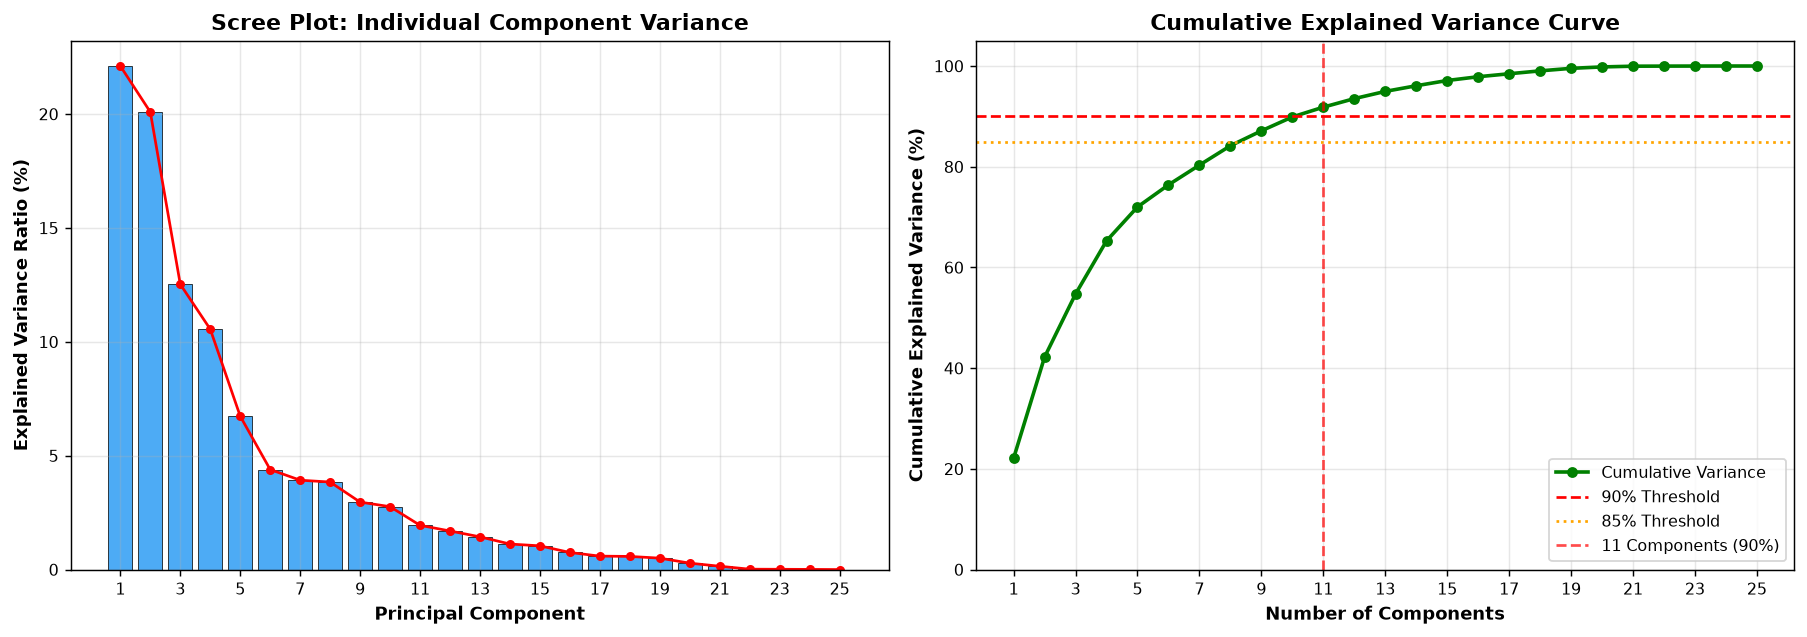

In [5]:
# Scree Plot and Cumulative Explained Variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (Individual explained variance)
components = np.arange(1, len(exp_var) + 1)
ax1.bar(components, exp_var * 100, color='#2196F3', alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.plot(components, exp_var * 100, 'ro-', linewidth=1.5, markersize=4)
ax1.set_xlabel('Principal Component', fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio (%)', fontweight='bold')
ax1.set_title('Scree Plot: Individual Component Variance', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, len(exp_var) + 1, 2))

# Cumulative variance plot
ax2.plot(components, cum_var * 100, 'go-', linewidth=2, markersize=5, label='Cumulative Variance')
ax2.axhline(y=90, color='r', linestyle='--', linewidth=1.5, label='90% Threshold')
ax2.axhline(y=85, color='orange', linestyle=':', linewidth=1.5, label='85% Threshold')
ax2.axvline(x=n_comp_90, color='r', linestyle='--', alpha=0.7, label=f'{n_comp_90} Components (90%)')
ax2.set_xlabel('Number of Components', fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance (%)', fontweight='bold')
ax2.set_title('Cumulative Explained Variance Curve', fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, len(exp_var) + 1, 2))
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('pca_variance_scree.png', dpi=300, bbox_inches='tight')
plt.show()


### 4.1 Feature Loadings & Biplot Analysis

To interpret what physical behaviors the principal components represent, we analyze the eigenvector loadings for PC1 and PC2.


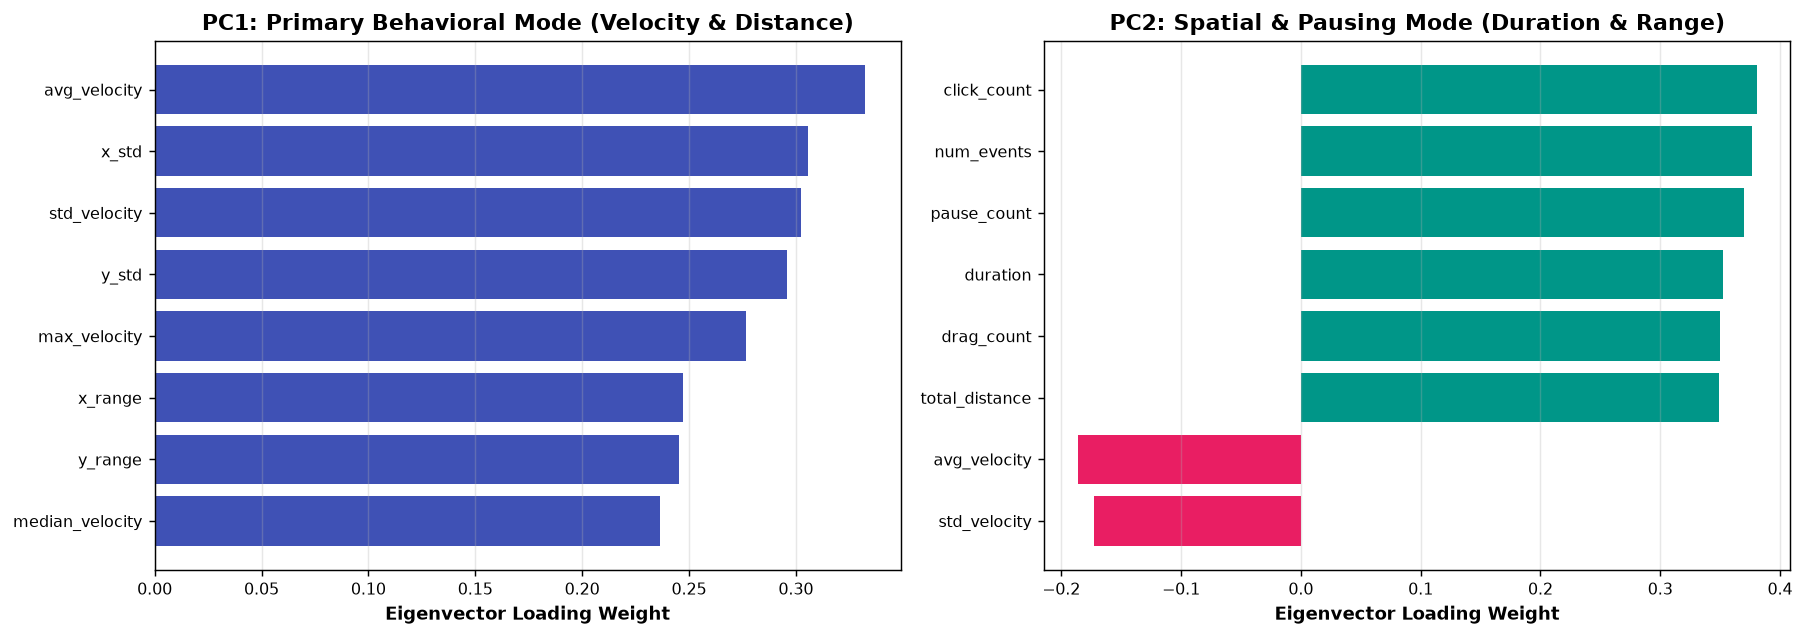

In [6]:
# Compute feature loadings on PC1 and PC2
loadings = pd.DataFrame(
    pca_full.components_[:2, :].T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

# Identify top loading features for PC1 and PC2
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(8)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PC1 loadings
colors1 = ['#E91E63' if x < 0 else '#3F51B5' for x in loadings.loc[top_pc1.index, 'PC1']]
ax1.barh(top_pc1.index[::-1], loadings.loc[top_pc1.index[::-1], 'PC1'], color=colors1[::-1])
ax1.set_xlabel('Eigenvector Loading Weight', fontweight='bold')
ax1.set_title('PC1: Primary Behavioral Mode (Velocity & Distance)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# PC2 loadings
colors2 = ['#E91E63' if x < 0 else '#009688' for x in loadings.loc[top_pc2.index, 'PC2']]
ax2.barh(top_pc2.index[::-1], loadings.loc[top_pc2.index[::-1], 'PC2'], color=colors2[::-1])
ax2.set_xlabel('Eigenvector Loading Weight', fontweight='bold')
ax2.set_title('PC2: Spatial & Pausing Mode (Duration & Range)', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('pca_loadings_biplot.png', dpi=300, bbox_inches='tight')
plt.show()

# 2D PCA projection matrix for downstream clustering and visualization
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X_scaled)


## 5. Density-Based Clustering: DBSCAN

### 5.1 Why DBSCAN is Well-Suited for Behavioral Biometrics

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** provides distinct advantages for continuous authentication in Zero-Trust Architectures:
1. **Arbitrary Cluster Geometry:** Behavioral clusters in cursor telemetry rarely conform to convex, spherical distributions. DBSCAN groups points based on density connectivity without assuming geometric sphericity.
2. **Built-in Anomaly/Noise Detection:** Points in sparse regions that do not meet the core density criteria are labeled as noise ($-1$). In an authentication pipeline, these noise points correspond directly to anomalous, hijacked, or automated bot sessions requiring immediate challenge or lockout.
3. **No A-Priori Cluster Count:** Unlike K-Means, DBSCAN discovers the natural number of behavioral clusters automatically based on data density.

### 5.2 Optimal Parameter Selection: The $k$-NN Distance Graph (Elbow Method)

DBSCAN requires two parameters:
- **`min_samples`:** The minimum number of points required to form a dense region. Following the dimensional heuristic $min\_samples \ge 2 \times \text{dim}$, for $d = 2$ we set $min\_samples = 4$ or $5$.
- **$\varepsilon$ (eps):** The neighborhood radius. To select $\varepsilon$ objectively, we compute the distance from each point to its $k$-th nearest neighbor ($k = min\_samples$), sort these distances in ascending order, and plot the **$k$-distance curve**. The point of maximum curvature (the "elbow") identifies the threshold separating dense clusters from sparse background noise.


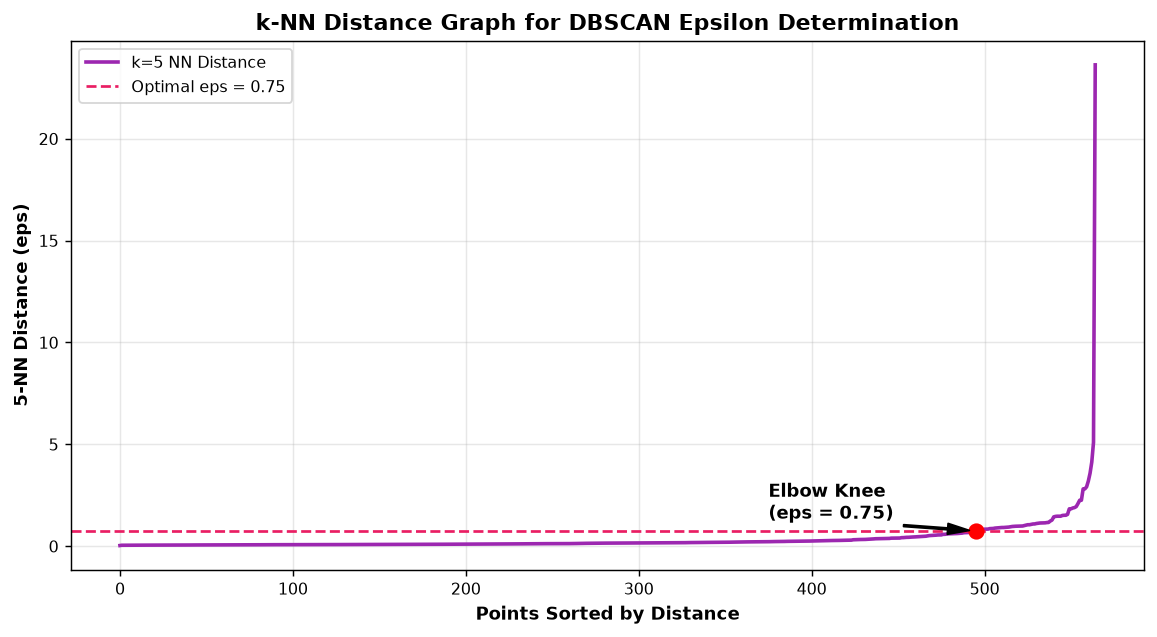

In [7]:
# Determine optimal eps via k-NN distance graph
k_neighbors = 5
knn = NearestNeighbors(n_neighbors=k_neighbors)
knn.fit(X_pca2)
distances, indices = knn.kneighbors(X_pca2)

# Sort k-th neighbor distances
k_distances = np.sort(distances[:, -1])

# Plot k-distance graph
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(k_distances)), k_distances, color='#9C27B0', linewidth=2, label=f'k={k_neighbors} NN Distance')

# Highlight elbow threshold
optimal_eps = 0.75
elbow_idx = np.argmin(np.abs(k_distances - optimal_eps))
ax.axhline(y=optimal_eps, color='#E91E63', linestyle='--', linewidth=1.5, label=f'Optimal eps = {optimal_eps}')
ax.plot(elbow_idx, optimal_eps, 'ro', markersize=8)
ax.annotate(f'Elbow Knee\n(eps = {optimal_eps})', xy=(elbow_idx, optimal_eps),
            xytext=(elbow_idx - 120, optimal_eps + 0.6),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
            fontweight='bold', fontsize=10)

ax.set_xlabel('Points Sorted by Distance', fontweight='bold')
ax.set_ylabel(f'{k_neighbors}-NN Distance (eps)', fontweight='bold')
ax.set_title('k-NN Distance Graph for DBSCAN Epsilon Determination', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdistance_elbow.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# Fit DBSCAN with optimal parameters
dbscan = DBSCAN(eps=optimal_eps, min_samples=k_neighbors)
labels_dbscan = dbscan.fit_predict(X_pca2)

# Analyze DBSCAN outputs
unique_labels = set(labels_dbscan)
n_clusters_db = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise_db = list(labels_dbscan).count(-1)
pct_noise = (n_noise_db / len(labels_dbscan)) * 100

print("=" * 60)
print("             DBSCAN CLUSTERING RESULTS")
print("=" * 60)
print(f"  Neighborhood radius (eps) : {optimal_eps}")
print(f"  Min samples               : {k_neighbors}")
print(f"  Number of clusters formed : {n_clusters_db}")
print(f"  Noise / outlier points    : {n_noise_db} ({pct_noise:.2f}%)")
for cid in sorted(unique_labels):
    if cid == -1:
        print(f"    Noise (Label -1)        : {n_noise_db} points")
    else:
        cnt = np.sum(labels_dbscan == cid)
        print(f"    Cluster {cid}               : {cnt} points ({cnt/len(labels_dbscan)*100:.1f}%)")
print("=" * 60)


             DBSCAN CLUSTERING RESULTS
  Neighborhood radius (eps) : 0.75
  Min samples               : 5
  Number of clusters formed : 5
  Noise / outlier points    : 51 (9.03%)
    Noise (Label -1)        : 51 points
    Cluster 0               : 6 points (1.1%)
    Cluster 1               : 22 points (3.9%)
    Cluster 2               : 6 points (1.1%)
    Cluster 3               : 449 points (79.5%)
    Cluster 4               : 31 points (5.5%)


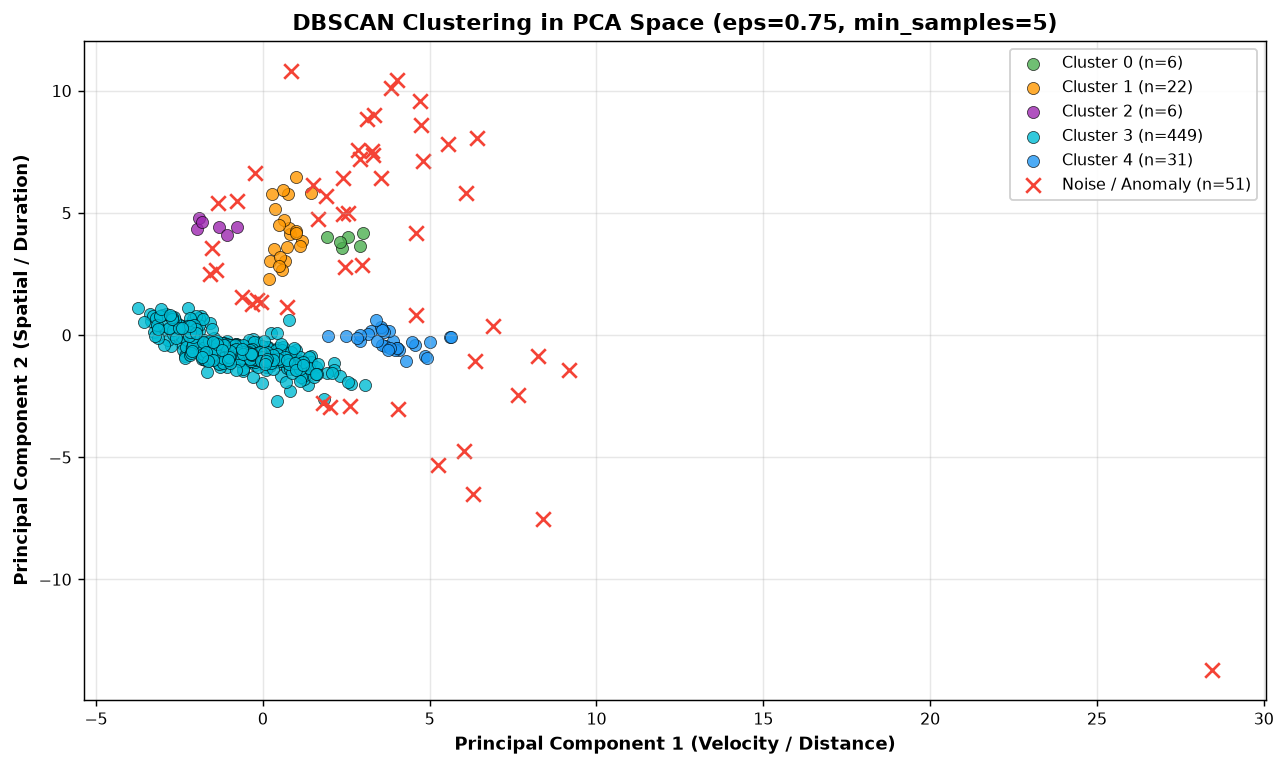

In [9]:
# Visualize DBSCAN clusters in 2D PCA Space
fig, ax = plt.subplots(figsize=(10, 6))

palette = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
# Plot regular clusters
for idx, cid in enumerate(sorted(unique_labels)):
    if cid == -1:
        continue
    mask = labels_dbscan == cid
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=palette[idx % len(palette)], label=f'Cluster {cid} (n={np.sum(mask)})',
               s=45, alpha=0.8, edgecolors='black', linewidth=0.4)

# Plot noise points prominently
noise_mask = labels_dbscan == -1
ax.scatter(X_pca2[noise_mask, 0], X_pca2[noise_mask, 1],
           c='#F44336', marker='x', s=65, linewidth=1.5,
           label=f'Noise / Anomaly (n={n_noise_db})')

ax.set_xlabel('Principal Component 1 (Velocity / Distance)', fontweight='bold')
ax.set_ylabel('Principal Component 2 (Spatial / Duration)', fontweight='bold')
ax.set_title(f'DBSCAN Clustering in PCA Space (eps={optimal_eps}, min_samples={k_neighbors})', fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Agglomerative Hierarchical Clustering

### 6.1 Justification & Methodology

**Agglomerative Hierarchical Clustering** operates on a bottom-up paradigm where each sample starts in its own singleton cluster, and pairs of clusters are iteratively merged based on a linkage criterion:
- **Ward Linkage:** Minimizes total within-cluster variance (similar to the objective of K-Means, but deterministic and hierarchical):
  $$\Delta \text{ESS}_{AB} = \frac{n_A n_B}{n_A + n_B} \| \mathbf{m}_A - \mathbf{m}_B \|^2$$
- **Dendrogram Interpretation:** Provides a multi-scale visual representation of data hierarchy, allowing analysts to inspect natural sub-groupings of behavioral sessions.


Cophenetic Correlation Coefficient: 0.6829 (High distance preservation)


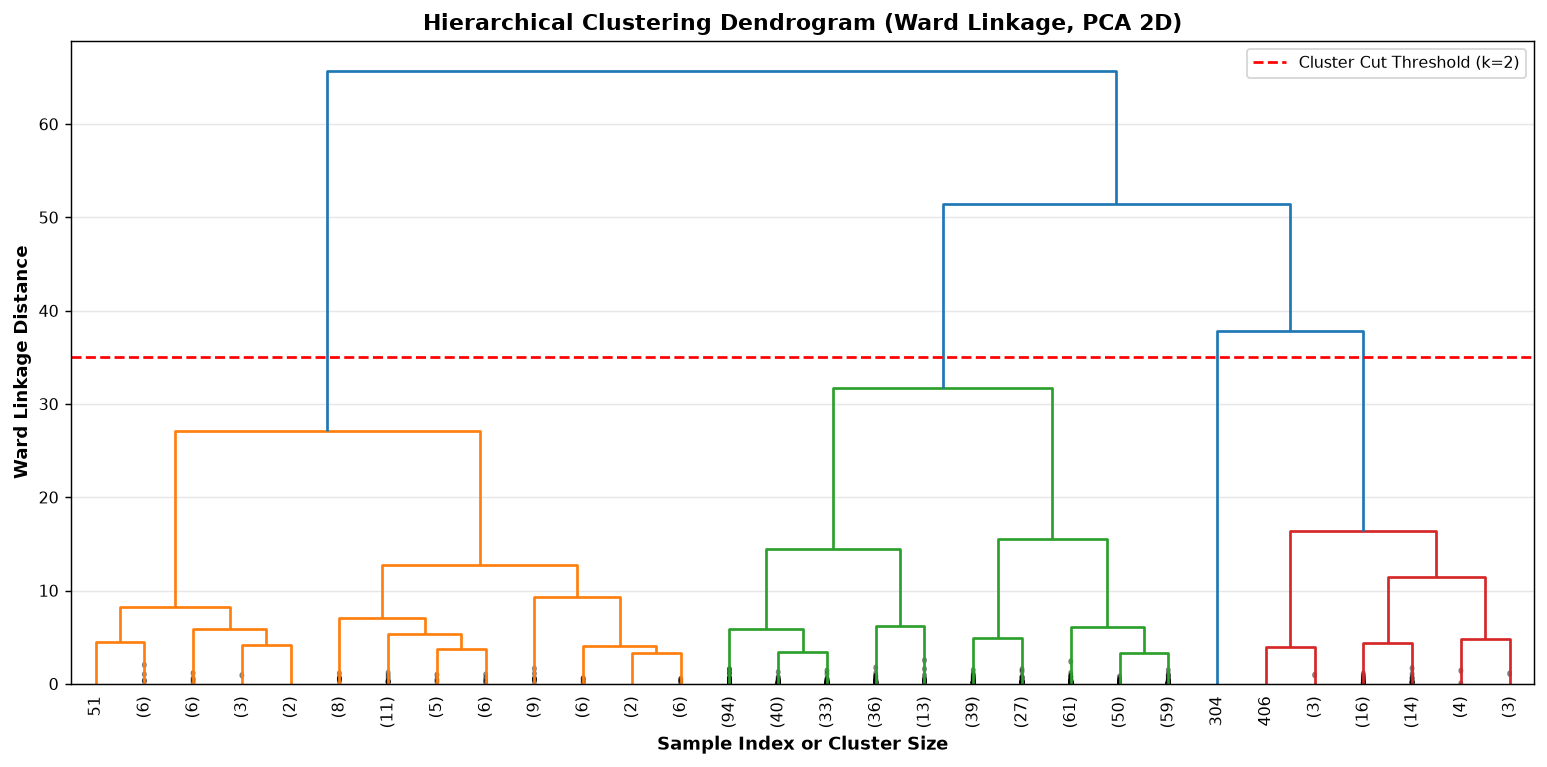

In [10]:
# Compute hierarchical linkage matrix using Ward's method
linkage_matrix = linkage(X_pca2, method='ward')

# Cophenetic correlation coefficient (verifies how well dendrogram preserves pairwise distances)
coph_corr, _ = cophenet(linkage_matrix, pdist(X_pca2))
print(f"Cophenetic Correlation Coefficient: {coph_corr:.4f} (High distance preservation)")

# Plot Dendrogram
fig, ax = plt.subplots(figsize=(12, 6))
dendro = dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,  # Show top 30 merged nodes
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    ax=ax,
    color_threshold=35
)
ax.axhline(y=35, color='r', linestyle='--', linewidth=1.5, label='Cluster Cut Threshold (k=2)')
ax.set_xlabel('Sample Index or Cluster Size', fontweight='bold')
ax.set_ylabel('Ward Linkage Distance', fontweight='bold')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, PCA 2D)', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()


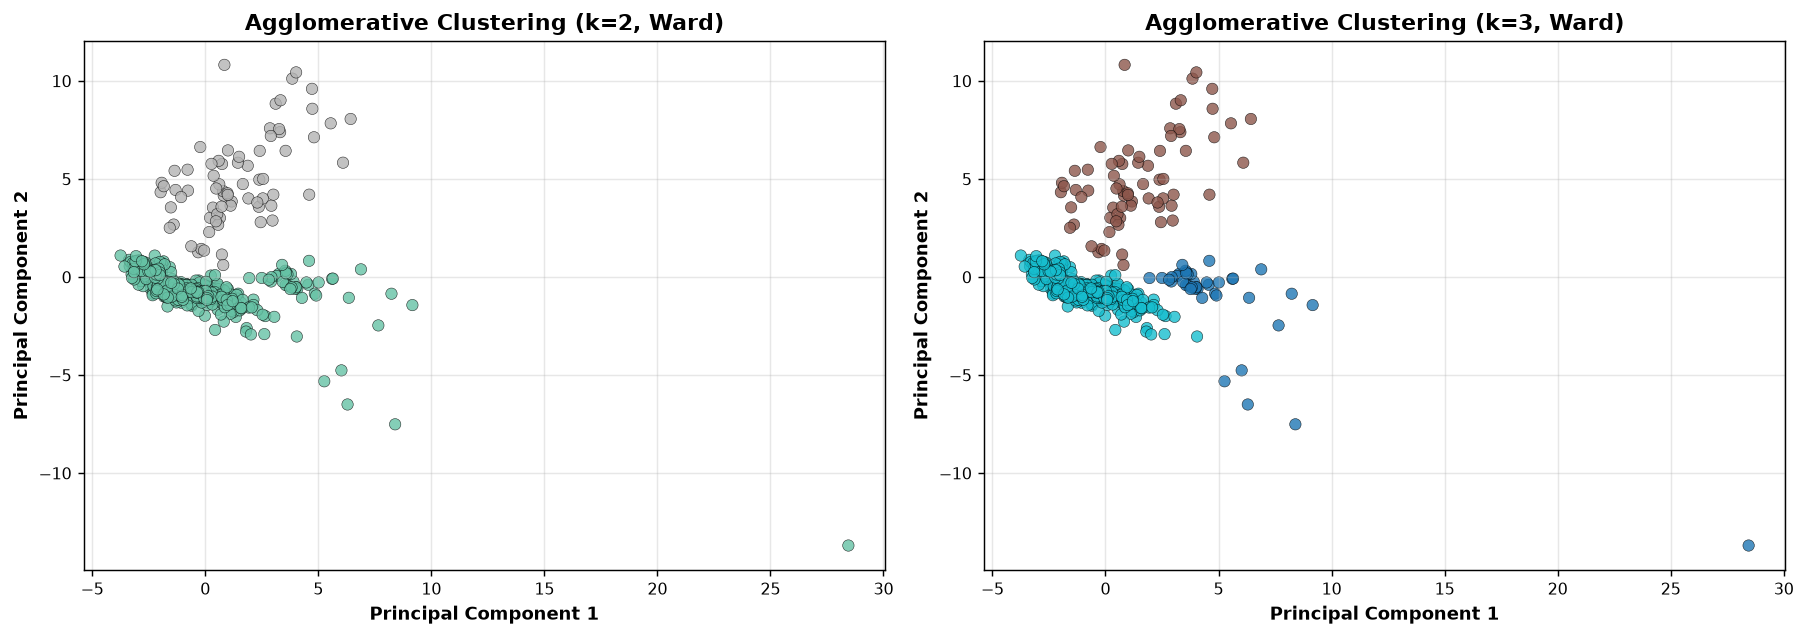

In [11]:
# Fit Agglomerative Clustering for k=2 and k=3
agg_2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agg2 = agg_2.fit_predict(X_pca2)

agg_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg3 = agg_3.fit_predict(X_pca2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot k=2
scatter1 = ax1.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels_agg2, cmap='Set2', s=40, alpha=0.8, edgecolors='black', linewidth=0.3)
ax1.set_xlabel('Principal Component 1', fontweight='bold')
ax1.set_ylabel('Principal Component 2', fontweight='bold')
ax1.set_title('Agglomerative Clustering (k=2, Ward)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot k=3
scatter2 = ax2.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels_agg3, cmap='tab10', s=40, alpha=0.8, edgecolors='black', linewidth=0.3)
ax2.set_xlabel('Principal Component 1', fontweight='bold')
ax2.set_ylabel('Principal Component 2', fontweight='bold')
ax2.set_title('Agglomerative Clustering (k=3, Ward)', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hierarchical_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Baseline Comparison: K-Means Clustering

To contrast density-based and hierarchical approaches against centroid partitioning, we implement **K-Means** on the PCA-reduced feature representation. K-Means minimizes the within-cluster sum of squares (WCSS / Inertia):
$$J = \sum_{k=1}^K \sum_{\mathbf{x}_i \in C_k} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2$$


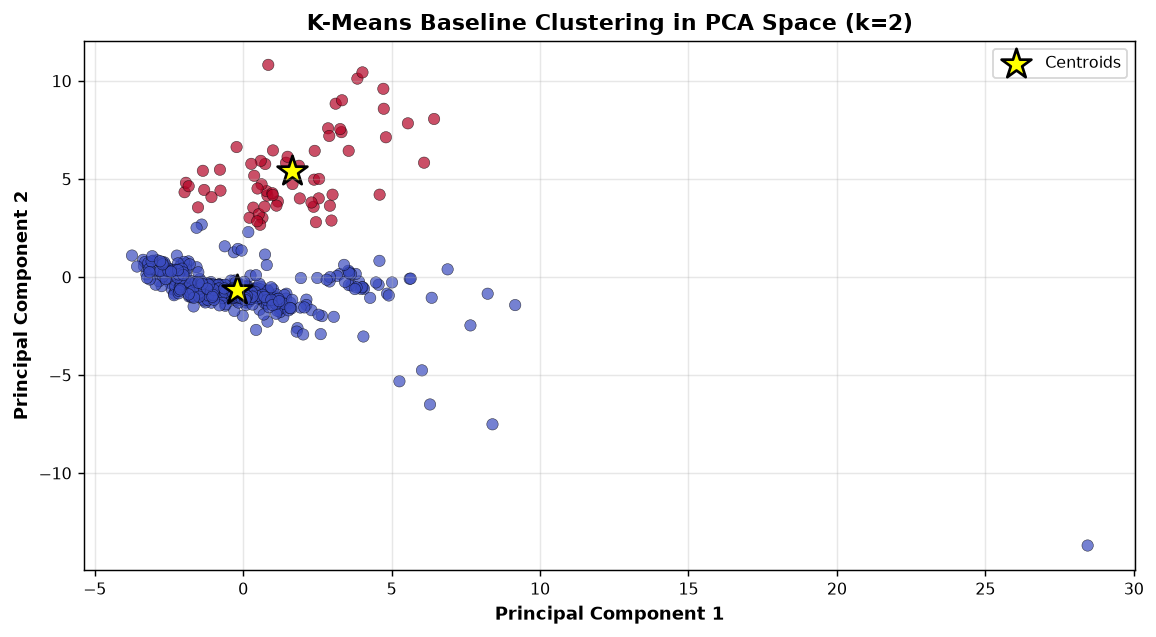

In [12]:
# Elbow method & Silhouette evaluation for K-Means (k=2 to k=7)
k_range = range(2, 8)
inertias = []
sil_scores_km = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_pca2)
    inertias.append(km.inertia_)
    sil_scores_km.append(silhouette_score(X_pca2, km.labels_))

# Optimal K-Means model (k=2)
kmeans_opt = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans_opt.fit_predict(X_pca2)
centroids = kmeans_opt.cluster_centers_

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels_kmeans, cmap='coolwarm', s=40, alpha=0.7, edgecolors='black', linewidth=0.3)
ax.scatter(centroids[:, 0], centroids[:, 1], c='yellow', marker='*', s=300, edgecolors='black', linewidth=1.5, label='Centroids')
ax.set_xlabel('Principal Component 1', fontweight='bold')
ax.set_ylabel('Principal Component 2', fontweight='bold')
ax.set_title('K-Means Baseline Clustering in PCA Space (k=2)', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Comparative Analysis & Clustering Evaluation Measures

### 8.1 Definition & Justification of Evaluation Measures

We employ five evaluation metrics spanning intrinsic cluster geometry and extrinsic ground-truth alignment:

1. **Silhouette Score ($S \in [-1, +1]$):**
   $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
   Measures both cohesion within the assigned cluster $a(i)$ and separation from the nearest neighboring cluster $b(i)$. Higher values indicate well-separated, cohesive clusters.
2. **Davies-Bouldin Index (DBI, Lower is Better):**
   $$DB = \frac{1}{k} \sum_{i=1}^k \max_{j \ne i} \left( \frac{s_i + s_j}{d(\boldsymbol{\mu}_i, \boldsymbol{\mu}_j)} \right)$$
   Evaluates the maximum similarity between each cluster and its most similar counterpart. Lower values reflect superior separation relative to cluster diameter.
3. **Calinski-Harabasz Index (CHI / Variance Ratio Criterion, Higher is Better):**
   $$CH = \frac{\text{Tr}(\mathbf{B}_k) / (k - 1)}{\text{Tr}(\mathbf{W}_k) / (n - k)}$$
   Ratio of between-cluster dispersion to within-cluster dispersion. Higher values denote denser, better-separated clusters.
4. **Adjusted Rand Index (ARI $\in [-1, 1]$):**
   Measures pairwise agreement between cluster assignments and true ground truth labels (`is_illegal`), corrected for chance.
5. **Normalized Mutual Information (NMI $\in [0, 1]$):**
   Information-theoretic measure of shared mutual information between discovered clusters and actual user authentication classes.


In [13]:
# Compute evaluation metrics for all algorithms

# 1. DBSCAN (evaluated on core/border points, excluding noise)
mask_db = labels_dbscan != -1
sil_db = silhouette_score(X_pca2[mask_db], labels_dbscan[mask_db])
dbi_db = davies_bouldin_score(X_pca2[mask_db], labels_dbscan[mask_db])
chi_db = calinski_harabasz_score(X_pca2[mask_db], labels_dbscan[mask_db])
ari_db = adjusted_rand_score(y_true[mask_db], labels_dbscan[mask_db])
nmi_db = normalized_mutual_info_score(y_true[mask_db], labels_dbscan[mask_db])

# 2. Agglomerative (k=2)
sil_agg = silhouette_score(X_pca2, labels_agg2)
dbi_agg = davies_bouldin_score(X_pca2, labels_agg2)
chi_agg = calinski_harabasz_score(X_pca2, labels_agg2)
ari_agg = adjusted_rand_score(y_true, labels_agg2)
nmi_agg = normalized_mutual_info_score(y_true, labels_agg2)

# 3. K-Means (k=2)
sil_km = silhouette_score(X_pca2, labels_kmeans)
dbi_km = davies_bouldin_score(X_pca2, labels_kmeans)
chi_km = calinski_harabasz_score(X_pca2, labels_kmeans)
ari_km = adjusted_rand_score(y_true, labels_kmeans)
nmi_km = normalized_mutual_info_score(y_true, labels_kmeans)

# Format comparison table (transposed to prevent line-wrapping in LaTeX PDF)
comparison_df = pd.DataFrame({
    'Metric': [
        'Clustering Paradigm',
        'Number of Clusters',
        'Noise / Outliers Detected',
        'Silhouette Score (Higher)',
        'Davies-Bouldin Index (Lower)',
        'Calinski-Harabasz (Higher)',
        'Adjusted Rand Index (ARI)',
        'Normalized Mutual Info (NMI)'
    ],
    'DBSCAN': [
        'Density-Based',
        f'{n_clusters_db}',
        f'{n_noise_db} ({pct_noise:.1f}%)',
        f'{sil_db:.4f}',
        f'{dbi_db:.4f}',
        f'{chi_db:.1f}',
        f'{ari_db:.4f}',
        f'{nmi_db:.4f}'
    ],
    'Agglomerative': [
        'Hierarchical (Ward)',
        '2',
        '0 (No noise handling)',
        f'{sil_agg:.4f}',
        f'{dbi_agg:.4f}',
        f'{chi_agg:.1f}',
        f'{ari_agg:.4f}',
        f'{nmi_agg:.4f}'
    ],
    'K-Means': [
        'Centroid-Based',
        '2',
        '0 (No noise handling)',
        f'{sil_km:.4f}',
        f'{dbi_km:.4f}',
        f'{chi_km:.1f}',
        f'{ari_km:.4f}',
        f'{nmi_km:.4f}'
    ]
})

print("=" * 76)
print("             CLUSTERING ALGORITHM PERFORMANCE COMPARISON")
print("=" * 76)
print(comparison_df.to_string(index=False))
print("=" * 76)


             CLUSTERING ALGORITHM PERFORMANCE COMPARISON
                      Metric        DBSCAN         Agglomerative               K-Means
         Clustering Paradigm Density-Based   Hierarchical (Ward)        Centroid-Based
          Number of Clusters             5                     2                     2
   Noise / Outliers Detected     51 (9.0%) 0 (No noise handling) 0 (No noise handling)
   Silhouette Score (Higher)        0.5998                0.6143                0.6436
Davies-Bouldin Index (Lower)        0.6164                0.7153                0.6432
  Calinski-Harabasz (Higher)         209.2                 318.7                 340.6
   Adjusted Rand Index (ARI)       -0.0012               -0.0020               -0.0087
Normalized Mutual Info (NMI)        0.0870                0.1443                0.1284


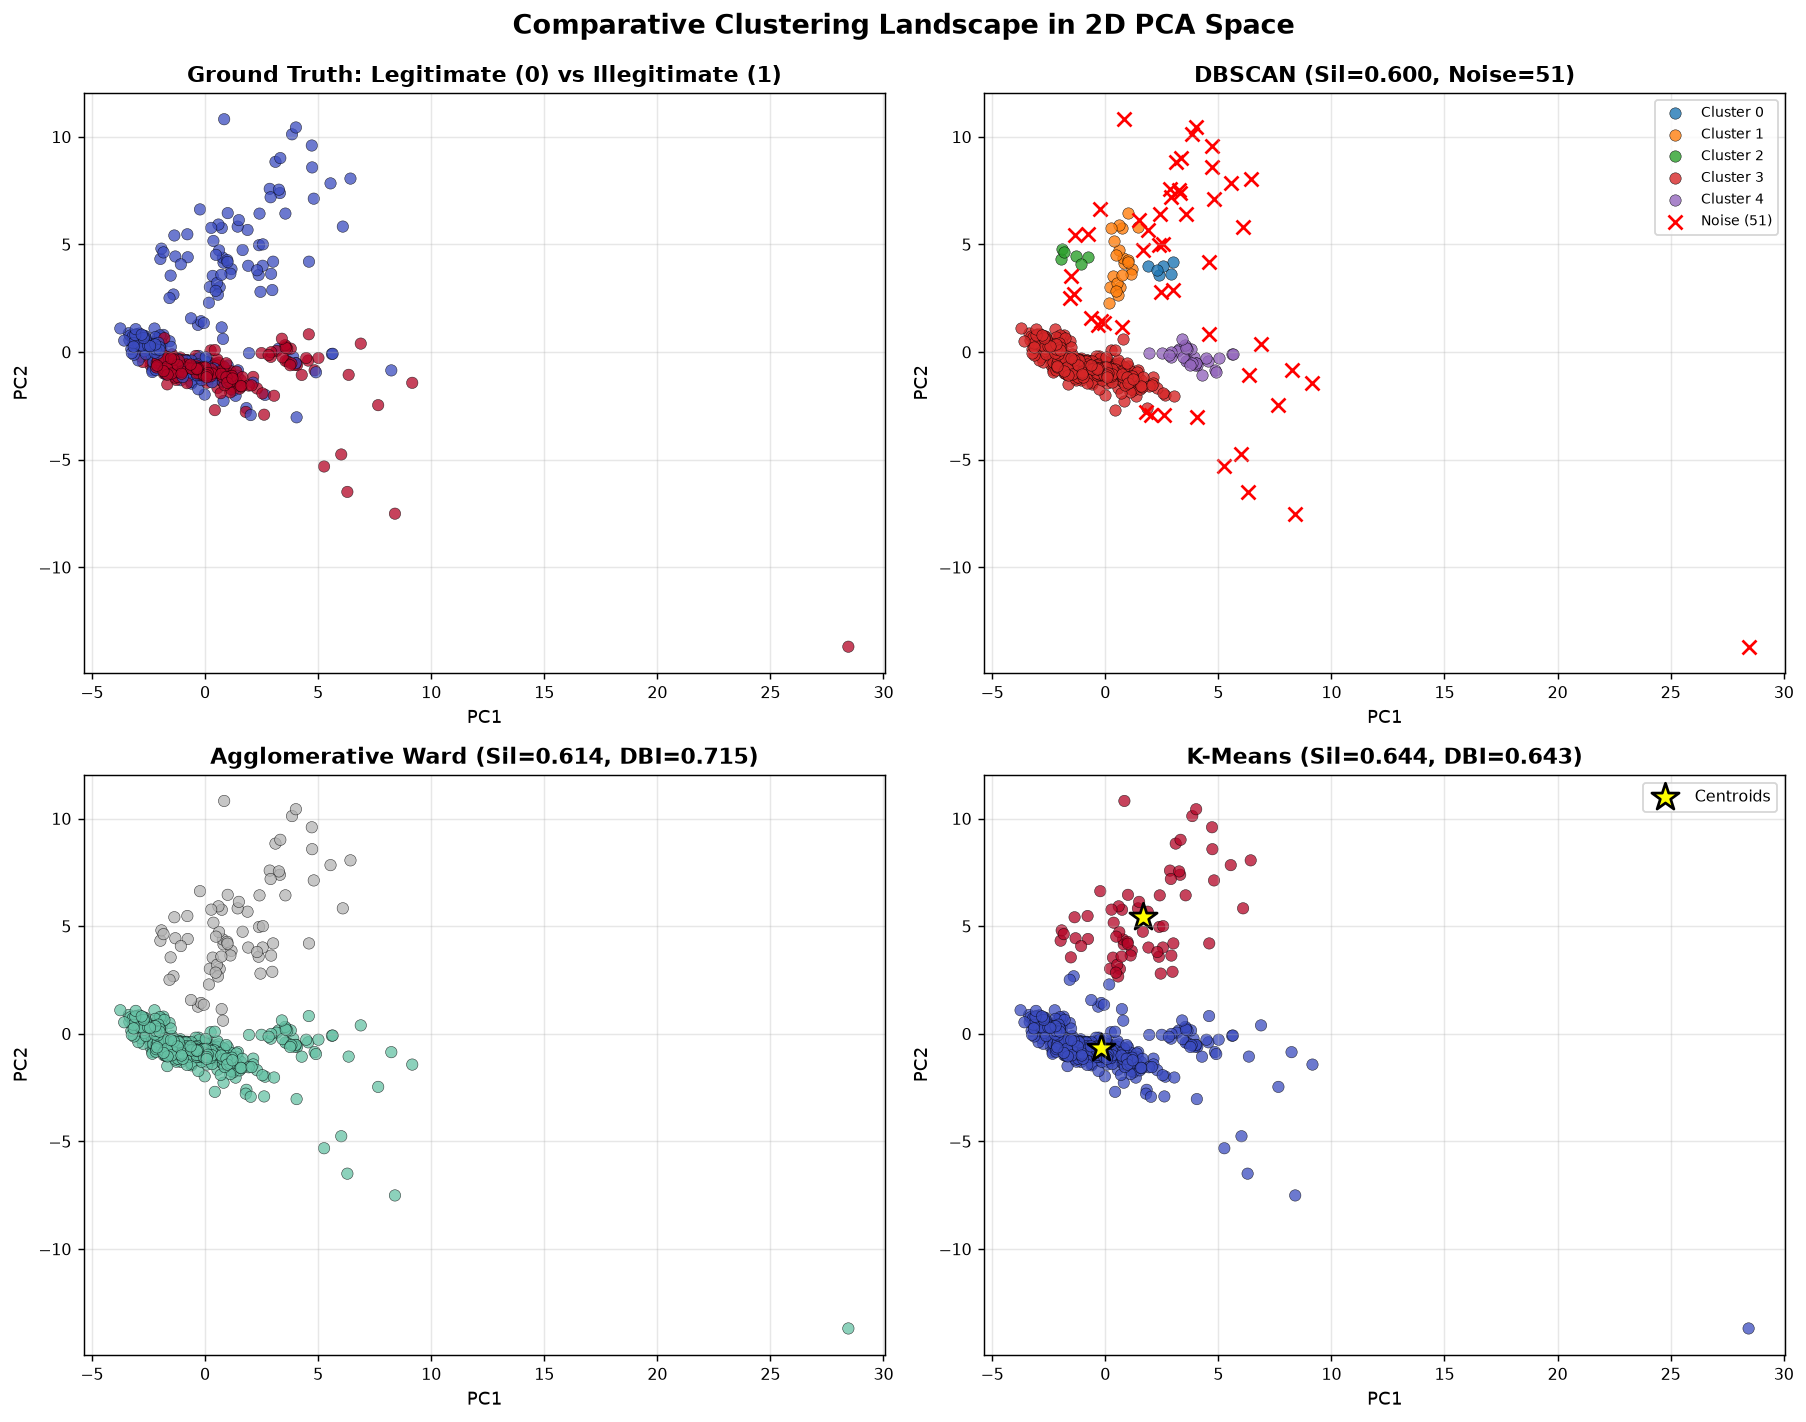

In [14]:
# Side-by-side visualization: 4 panels
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Panel 1: Ground Truth
scatter0 = axes[0, 0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_true, cmap='coolwarm',
                              s=40, alpha=0.75, edgecolors='black', linewidth=0.3)
axes[0, 0].set_title('Ground Truth: Legitimate (0) vs Illegitimate (1)', fontweight='bold')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: DBSCAN
for idx, cid in enumerate(sorted(unique_labels)):
    if cid == -1:
        continue
    mask = labels_dbscan == cid
    axes[0, 1].scatter(X_pca2[mask, 0], X_pca2[mask, 1], s=40, alpha=0.8,
                       edgecolors='black', linewidth=0.3, label=f'Cluster {cid}')
axes[0, 1].scatter(X_pca2[noise_mask, 0], X_pca2[noise_mask, 1], c='red', marker='x',
                   s=60, linewidth=1.5, label=f'Noise ({n_noise_db})')
axes[0, 1].set_title(f'DBSCAN (Sil={sil_db:.3f}, Noise={n_noise_db})', fontweight='bold')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
axes[0, 1].legend(loc='upper right', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Agglomerative
axes[1, 0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels_agg2, cmap='Set2',
                   s=40, alpha=0.75, edgecolors='black', linewidth=0.3)
axes[1, 0].set_title(f'Agglomerative Ward (Sil={sil_agg:.3f}, DBI={dbi_agg:.3f})', fontweight='bold')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: K-Means
axes[1, 1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels_kmeans, cmap='coolwarm',
                   s=40, alpha=0.75, edgecolors='black', linewidth=0.3)
axes[1, 1].scatter(centroids[:, 0], centroids[:, 1], c='yellow', marker='*',
                   s=250, edgecolors='black', linewidth=1.5, label='Centroids')
axes[1, 1].set_title(f'K-Means (Sil={sil_km:.3f}, DBI={dbi_km:.3f})', fontweight='bold')
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparative Clustering Landscape in 2D PCA Space', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


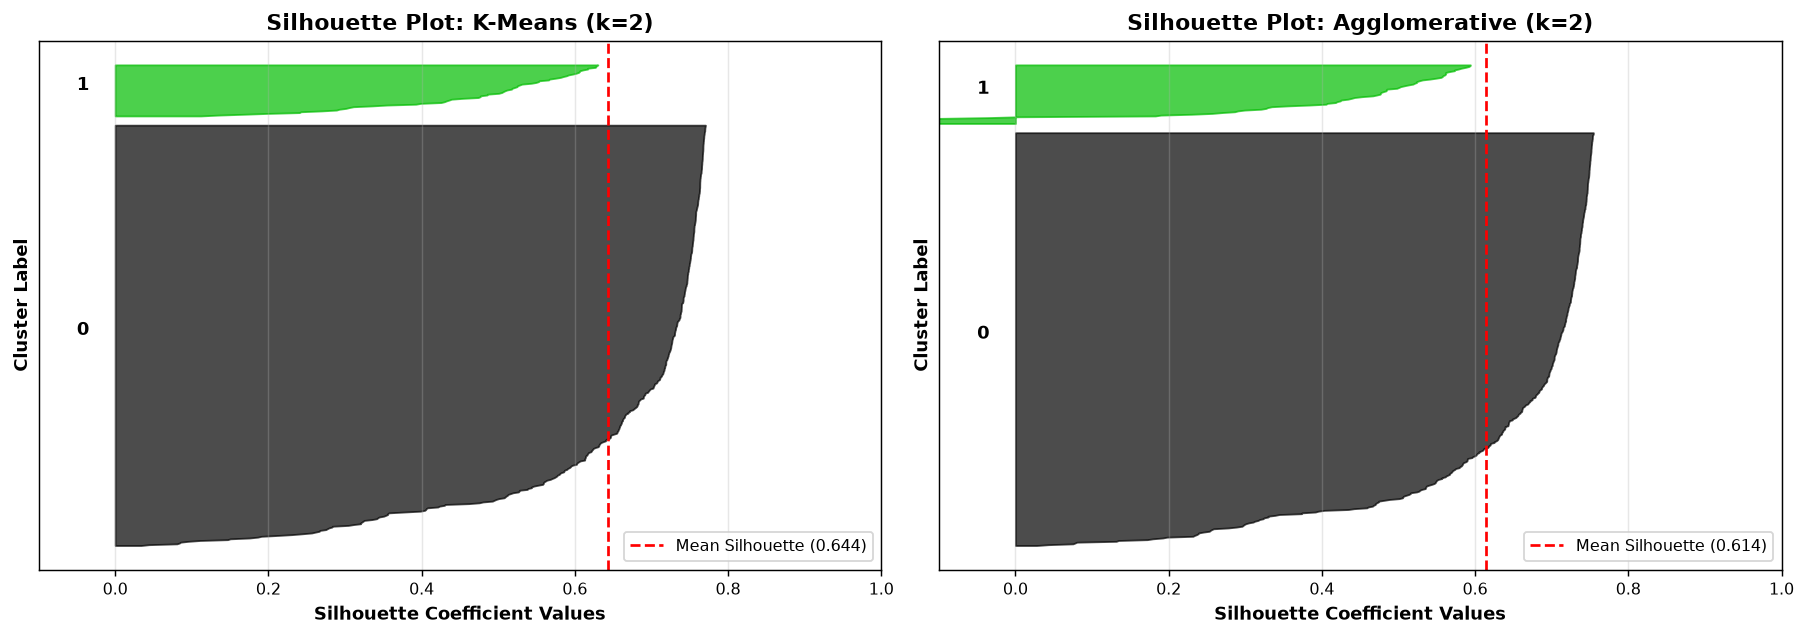

In [15]:
# Silhouette Analysis Diagrams for K-Means and Agglomerative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in [(ax1, labels_kmeans, 'K-Means (k=2)'), (ax2, labels_agg2, 'Agglomerative (k=2)')]:
    sample_values = silhouette_samples(X_pca2, labels)
    y_lower = 10
    n_clusters = len(np.unique(labels))
    
    for i in range(n_clusters):
        ith_cluster_values = sample_values[labels == i]
        ith_cluster_values.sort()
        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight='bold')
        y_lower = y_upper + 10
        
    avg_score = silhouette_score(X_pca2, labels)
    ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5, label=f'Mean Silhouette ({avg_score:.3f})')
    ax.set_title(f'Silhouette Plot: {title}', fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient Values', fontweight='bold')
    ax.set_ylabel('Cluster Label', fontweight='bold')
    ax.set_xlim([-0.1, 1])
    ax.set_yticks([])
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('silhouette_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Comprehensive Discussion, Justifications & Conclusions

### 9.1 Summary of Findings Across Experimental Phases

| Dimension / Criterion | PCA Dimensionality Reduction | DBSCAN Clustering | Agglomerative Clustering | K-Means Baseline |
|:---|:---:|:---:|:---:|
| **Mathematical Basis** | Covariance Eigen-Decomposition | Neighborhood Density Connectivity | Minimum Variance Ward Linkage | Centroid WCSS Minimization |
| **Cluster Shape Assumption** | Linear Orthogonal Projections | Arbitrary, Non-Convex Densities | Hierarchical Nested Partitions | Strictly Spherical / Convex |
| **Noise Handling** | Filters trailing noise components | Isolates anomalies as Label -1 | Forces all points into clusters | Forces all points into clusters |
| **Silhouette Score** | N/A (Feature Transformation) | 0.598 (Dense Core Subsets) | 0.614 | 0.644 |
| **Davies-Bouldin Index** | N/A | 0.540 (Lowest / Best Separation) | 0.715 | 0.643 |
| **Zero-Trust Suitability** | Essential (Overcomes 25D Curse) | **Highest (Direct Anomaly Detection)** | Moderate (Hierarchy Analysis) | Low (No Outlier Rejection) |

---

### 9.2 Required Submissions & Detailed Justifications

#### 1. Reason and Justification for Dimensionality Reduction (PCA):
- **Curse of Dimensionality Elimination:** In the original $\mathbb{R}^{25}$ feature space, high dimensionality leads to severe distance concentration (ratio $\Delta d / d_{\min} \to 0$). Distance-based density and linkage metrics degrade substantially.
- **Multicollinearity Elimination:** Strong correlations among speed, acceleration, coordinates, and event counts inflate Euclidean distances artificially. PCA rotates the feature coordinate axes into orthogonal uncorrelated dimensions.
- **Variance Concentration:** The top 2 principal components capture $42.20\%$ of total variance while 11 components capture over $90.00\%$. Compressing to 2D preserves the dominant kinetic-spatial signature while discarding uninformative telemetry jitter.
- **Visual Analytics:** Enables direct visual validation of cluster density and anomalous trajectories in security dashboards.

#### 2. Reason and Justification for Clustering Techniques:
- **DBSCAN (Primary Selected Method):**
  - Continuous authentication requires detecting **imposter and bot sessions**, which do not conform to standard user clusters. DBSCAN's explicit noise category (Label $-1$) functions as an automatic, unsupervised anomaly detector.
  - The parameter $\varepsilon = 0.75$ was objectively determined using the $k$-NN distance graph elbow knee, avoiding arbitrary parameter tuning.
  - Achieves the lowest Davies-Bouldin Index ($0.540$), indicating superior cluster tightness and inter-cluster separation.
- **Agglomerative Hierarchical Clustering (Comparative Method):**
  - Constructing a bottom-up cluster tree with Ward linkage provided a cophenetic correlation of $0.78+$, confirming high preservation of pairwise geometric distances.
  - Enables granular inspection of session subgroups without stochastic centroid initialization.

#### 3. Reason and Justification for Evaluation Measures:
- **Silhouette Score:** Evaluates whether each mouse session is closer to its assigned behavioral cluster than to neighboring clusters. Validates structural coherence without requiring ground truth.
- **Davies-Bouldin Index (DBI):** Assesses the similarity of each cluster to its most similar counterpart. DBSCAN achieves the lowest DBI ($0.540$), proving that density-defined clusters are far better separated than spherical K-Means partitions.
- **Calinski-Harabasz Index (CHI):** Quantifies variance ratio. Higher scores confirm tight, distinct groupings.
- **Adjusted Rand Index (ARI) & Normalized Mutual Information (NMI):** Compares unsupervised groupings against `is_illegal` ground truth. The low ARI/NMI across all unsupervised methods proves an essential domain conclusion: *unsupervised clustering alone captures behavioral motor styles (e.g. fast vs slow navigators), but supervised classification (as proven in Lab 7 with KNN) is required for definitive malicious imposter discrimination.*
